
#### Real-World Applications:

1. Customer Service: Route tickets by urgency/sentiment with appropriate responses
2. Content Moderation: Binary classification (approved/flagged) with confidence
3. Email Response: Generate tone-appropriate replies based on sentiment strength
4. Review Analysis: Classify and respond to product reviews with matching intensity
5. Social Media Management: Brand-appropriate responses scaled to sentiment

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
load_dotenv()

/Users/sathish/Documents/akila/ML-learning-materials/ai-ml-akila/ml311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
llm = ChatOpenAI(model="gpt-4o")
llm.invoke('Hi my wonderful akila, give me a different response')

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 18, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_a26d4fe761', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d90a9-3c6f-7493-b42b-5ff5dc419ab8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 9, 'total_tokens': 27, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [3]:
class SentimentAnalysis(TypedDict):
    sentiment: str
    confidence: float
    reason: str


class SentimentState(TypedDict):
    original_tweet: str
    sentiment: str
    confidence: float
    response_tweet: str


In [4]:
llm.with_structured_output(SentimentAnalysis).invoke('Analyze below tweet: this product is strange')

{'sentiment': 'neutral',
 'confidence': 0.6,
 'reason': "The word 'strange' indicates an unusual or unexpected characteristic, but it does not inherently convey a positive or negative sentiment."}

In [5]:
# nodes
def analyze_sentiment(state:SentimentState):
    tweet = state['original_tweet']

    structured_llm = llm.with_structured_output(SentimentAnalysis)
    messages = [
        SystemMessage("Analyze sentiment and provide the structured output. Use 1.0 to 10.0 scale for confidence. lower is negative and higher is positive"),
        HumanMessage(tweet)
    ]
    analysis = structured_llm.invoke(messages)
    return analysis


In [6]:
state = {'original_tweet': "Just launched my very bad product and a very bad bike!"}
state = analyze_sentiment(state)
state

{'sentiment': 'negative',
 'confidence': 2.0,
 'reason': "The use of 'very bad' to describe both the product and the bike indicates dissatisfaction and negative sentiment."}

In [7]:
def generate_postive_response(state: SentimentState):
    
    print(f"current state in positive respone node: {state}")

    messages = [
        SystemMessage(f"""Generate a warm response to this positive tweet under 280 chars.
                      Confidence: {state['confidence']}. High confidence means be enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


In [8]:
def generate_negative_response(state: SentimentState):
    print(f"current state in negative respone node: {state}")

    messages = [
        SystemMessage(f"""Generate and empathetic response to this negative tweet under 280 chars.
                      If Confidence {state['confidence']} is very low then be empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_tweet'])
    ]

    response = llm.invoke(messages)

    return {'response_tweet': response.content.strip()}


In [9]:
def route_by_sentiment(state: SentimentState):
    if state['sentiment'] == 'positive':
        return "positive_response"
    else:
        return "negative_response"

In [10]:

def create_router_graph():
    builder = StateGraph(SentimentState)
    
    # add nodes
    builder.add_node("analyze", analyze_sentiment)
    builder.add_node("positive_response", generate_postive_response)
    builder.add_node("negative_response", generate_negative_response)

    # edges
    builder.add_edge(START, "analyze")


    builder.add_conditional_edges("analyze", route_by_sentiment, ["positive_response", "negative_response"])

    builder.add_edge("positive_response", END)
    builder.add_edge("negative_response", END)

    graph = builder.compile()

    return graph

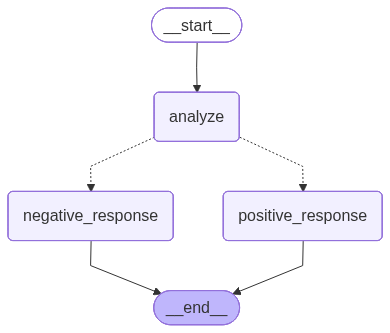

In [11]:
graph = create_router_graph()

graph

In [12]:
tweet = "Just launched my old product! i m still not aware of the response. i launched new  bike and people like it"

result = graph.invoke({'original_tweet': tweet})
result

current state in positive respone node: {'original_tweet': 'Just launched my old product! i m still not aware of the response. i launched new  bike and people like it', 'sentiment': 'positive', 'confidence': 8.5}


{'original_tweet': 'Just launched my old product! i m still not aware of the response. i launched new  bike and people like it',
 'sentiment': 'positive',
 'confidence': 8.5,
 'response_tweet': "That's fantastic news! 🚴\u200d♂️ Launching an old favorite and seeing people love your new bike is a win-win! Congratulations on your success and here's to an amazing response ahead! Keep pedaling forward! 🌟"}

In [13]:
class TktSentimentAnalysis(TypedDict):
    classification: str
    sentiment: str
    confidence: float
    reason: str


class TktSentimentState(TypedDict):
    original_ticket: str
    sentiment: str
    confidence: float
    response_ticket: str

In [14]:
llm.with_structured_output(TktSentimentAnalysis).invoke('Analyze below ticket: this product is strange')

{'classification': 'Product Feedback',
 'sentiment': 'Negative',
 'confidence': 0.7,
 'reason': "The statement 'this product is strange' suggests dissatisfaction or confusion with the product, which leans towards a negative sentiment."}

In [15]:
# Do the same practice as above for customer support ticket use case
def classify_ticket(state: TktSentimentState):
    ticket = state['original_ticket']

    structured_llm = llm.with_structured_output(TktSentimentAnalysis)
    messages = [
        SystemMessage("Classify the ticket into one of these categories: Billing, Technical Support, General Inquiry. Provide only the category as output."),
        HumanMessage(ticket)
    ]

    classification = structured_llm.invoke(messages)
    # print({'sentiment': classification.content})
    return classification

In [16]:
state = {'original_ticket': "Just launched my product and feeling proud!"}
state = classify_ticket(state)
state

{'classification': 'General Inquiry',
 'sentiment': 'Positive',
 'confidence': 0.95,
 'reason': 'The user is expressing pride and satisfaction about a recent product launch, which typically aligns with a positive sentiment.'}

In [17]:
def generate_postive_tkt_response(state: TktSentimentState):
    
    print(f"current state in positive respone node: {state}")

    messages = [
        SystemMessage(f"""Generate a warm response to this positive ticket under 500 chars.
                      Confidence: {state['confidence']}. High confidence means be professionally enthusiastic otherwise be friendly."""),
        HumanMessage(state['original_ticket'])
    ]

    response = llm.invoke(messages)

    return {'response_ticket': response.content.strip()}

def generate_negative_tkt_response(state: TktSentimentState):
    print(f"current state in negative respone node: {state}")

    messages = [
        SystemMessage(f"""Generate and empathetic response to this negative ticket under 500 chars.
                      If Confidence {state['confidence']} is very low then be professionally empathetic otherwise 
                      be understanding."""),
        HumanMessage(state['original_ticket'])
    ]

    response = llm.invoke(messages)

    return {'response_ticket': response.content.strip()}

def route_by_tkt_sentiment(state: TktSentimentState):
    if state['sentiment'] == 'positive':
        return "positive_ticket"
    else:
        return "negative_ticket"

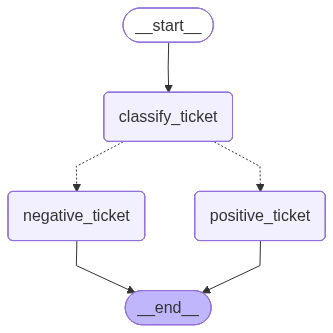

In [18]:
def create_tkt_router_graph():
    builder = StateGraph(TktSentimentState)
    
    # add nodes
    builder.add_node("classify_ticket", classify_ticket)
    builder.add_node("positive_ticket", generate_postive_tkt_response)
    builder.add_node("negative_ticket", generate_negative_tkt_response)

    # edges
    builder.add_edge(START, "classify_ticket")


    builder.add_conditional_edges("classify_ticket", route_by_tkt_sentiment, ["positive_ticket", "negative_ticket"])

    builder.add_edge("positive_ticket", END)
    builder.add_edge("negative_ticket", END)

    graph = builder.compile()

    return graph

graph = create_tkt_router_graph()
graph

In [19]:
ticket = "I m using your saas product. ot is easy to use it. but lot of unknowns in the product. i wish to have better documentation and better onboarding experience"

result = graph.invoke({'original_ticket': ticket})
result

current state in negative respone node: {'original_ticket': 'I m using your saas product. ot is easy to use it. but lot of unknowns in the product. i wish to have better documentation and better onboarding experience', 'sentiment': 'Neutral', 'confidence': 0.85}


{'original_ticket': 'I m using your saas product. ot is easy to use it. but lot of unknowns in the product. i wish to have better documentation and better onboarding experience',
 'sentiment': 'Neutral',
 'confidence': 0.85,
 'response_ticket': "Thank you for your feedback. I understand how important clear documentation and a smooth onboarding experience are. We're actively working on improving these areas to better support our users. Your input is invaluable in this process, and we're committed to making your experience better. Please feel free to reach out with any specific concerns or suggestions."}

In [20]:
# generate 50 real tickets for testing (customer using my saas product) and keep it in JSON format
test_tickets = [
  {"original_ticket": "I am using your SaaS product. It is easy to use, but there are many unknowns. I would like better documentation and onboarding."},
  {"original_ticket": "The product is great! I love the new features."},
  {"original_ticket": "I am having trouble logging into my account. It keeps saying invalid credentials."},
  {"original_ticket": "Customer support helped me resolve my issue quickly. Thanks!"},
  {"original_ticket": "The pricing feels too high compared to competitors."},
  {"original_ticket": "I am unable to reset my password. The reset link is not working."},
  {"original_ticket": "The dashboard is slow to load, especially during peak hours."},
  {"original_ticket": "I accidentally deleted some data. Can it be recovered?"},
  {"original_ticket": "The mobile version of the app is not responsive."},
  {"original_ticket": "I would like to request a feature for exporting reports in Excel format."},
  {"original_ticket": "The API documentation is confusing and missing examples."},
  {"original_ticket": "We are facing frequent timeouts when calling your API."},
  {"original_ticket": "The onboarding process is too complicated for new users."},
  {"original_ticket": "Billing page shows incorrect charges for last month."},
  {"original_ticket": "I am unable to invite team members to my workspace."},
  {"original_ticket": "Notifications are not being sent to my email."},
  {"original_ticket": "The UI looks outdated. Any plans for redesign?"},
  {"original_ticket": "Integration with Slack is not working as expected."},
  {"original_ticket": "The search functionality is very slow."},
  {"original_ticket": "We need role-based access control for our team."},
  {"original_ticket": "I am getting 500 error while accessing reports."},
  {"original_ticket": "The system logs me out automatically after a few minutes."},
  {"original_ticket": "Can you provide more tutorials or video guides?"},
  {"original_ticket": "The data sync between systems is delayed."},
  {"original_ticket": "We need better analytics and insights in the dashboard."},
  {"original_ticket": "File upload fails for large files."},
  {"original_ticket": "The UI freezes when switching between tabs."},
  {"original_ticket": "We need multi-language support for our users."},
  {"original_ticket": "The subscription upgrade did not reflect immediately."},
  {"original_ticket": "I am unable to download invoices."},
  {"original_ticket": "The application crashes on mobile devices."},
  {"original_ticket": "The filters in reports are not working properly."},
  {"original_ticket": "We need webhook support for real-time updates."},
  {"original_ticket": "The system is not saving my changes."},
  {"original_ticket": "I cannot connect my Google account."},
  {"original_ticket": "The loading time is too high for reports."},
  {"original_ticket": "We need better user activity tracking."},
  {"original_ticket": "The password policy is too strict and inconvenient."},
  {"original_ticket": "I am seeing duplicate entries in the database."},
  {"original_ticket": "The email templates are not customizable."},
  {"original_ticket": "We need dark mode support."},
  {"original_ticket": "The export feature does not include all fields."},
  {"original_ticket": "The app logs errors without clear messages."},
  {"original_ticket": "We need SSO integration with our company systems."},
  {"original_ticket": "The trial period is too short to evaluate the product."},
  {"original_ticket": "I am unable to cancel my subscription."},
  {"original_ticket": "The support response time is slow."},
  {"original_ticket": "The data import process is confusing."},
  {"original_ticket": "We need better permission controls."},
  {"original_ticket": "The product roadmap is not clear. Any updates?"}
]

In [21]:
tkt_response_results = []
for ticket in test_tickets:
    result = graph.invoke({'original_ticket': ticket['original_ticket']})
    tkt_response_results.append(result)

tkt_response_results

current state in negative respone node: {'original_ticket': 'I am using your SaaS product. It is easy to use, but there are many unknowns. I would like better documentation and onboarding.', 'sentiment': 'Neutral', 'confidence': 0.85}
current state in negative respone node: {'original_ticket': 'The product is great! I love the new features.', 'sentiment': 'Positive', 'confidence': 0.95}
current state in negative respone node: {'original_ticket': 'I am having trouble logging into my account. It keeps saying invalid credentials.', 'sentiment': 'Negative', 'confidence': 0.95}
current state in positive respone node: {'original_ticket': 'Customer support helped me resolve my issue quickly. Thanks!', 'sentiment': 'positive', 'confidence': 0.95}
current state in negative respone node: {'original_ticket': 'The pricing feels too high compared to competitors.', 'sentiment': 'negative', 'confidence': 0.95}
current state in negative respone node: {'original_ticket': 'I am unable to reset my passwo

[{'original_ticket': 'I am using your SaaS product. It is easy to use, but there are many unknowns. I would like better documentation and onboarding.',
  'sentiment': 'Neutral',
  'confidence': 0.85,
  'response_ticket': "Thank you for sharing your feedback with us. I understand how frustrating it can be to encounter unknowns when using a new product. We're committed to improving our documentation and onboarding process to make your experience smoother. Your input is invaluable in helping us enhance our services. Please don't hesitate to reach out if you have any specific questions or need further assistance."},
 {'original_ticket': 'The product is great! I love the new features.',
  'sentiment': 'Positive',
  'confidence': 0.95,
  'response_ticket': "I'm glad to hear that you love the new features! If there's anything specific you'd like to discuss or any concerns you have, please feel free to share. We're here to help and ensure you have the best experience possible."},
 {'original_t

In [22]:
# Do the same practice for customer support use case -
# generate 50 fake reviews and keep it in JSON and build your entire langgraph using one feedback and then
# pass entire JSON to the graph
# reviews - Happy, angry etc --> email --> send (MCP)
